
📊 Model Comparison:
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.703045  0.622811


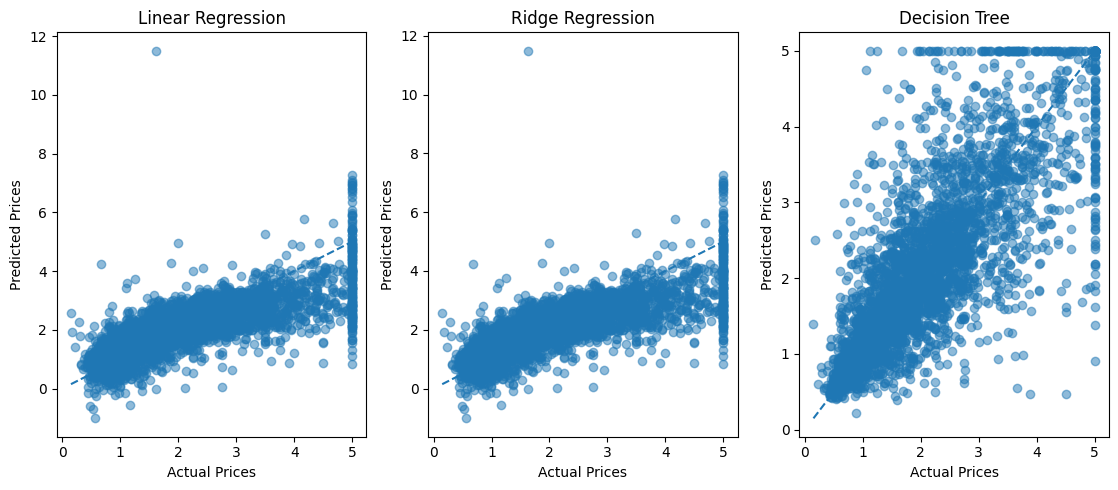

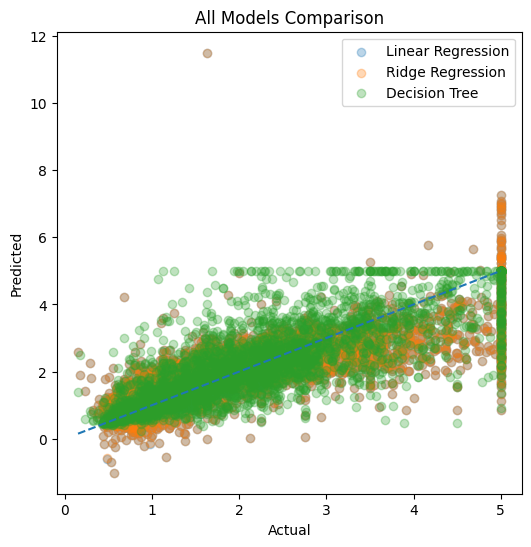


🏆 Best Model: Decision Tree
RMSE: 0.7030
R2 Score: 0.6228

📌 Model Selection Justification:
Decision Tree performed best because it achieved the highest R2 score and lowest RMSE, indicating better prediction accuracy.
It is capable of capturing non-linear relationships in the dataset, which linear models could not handle effectively.


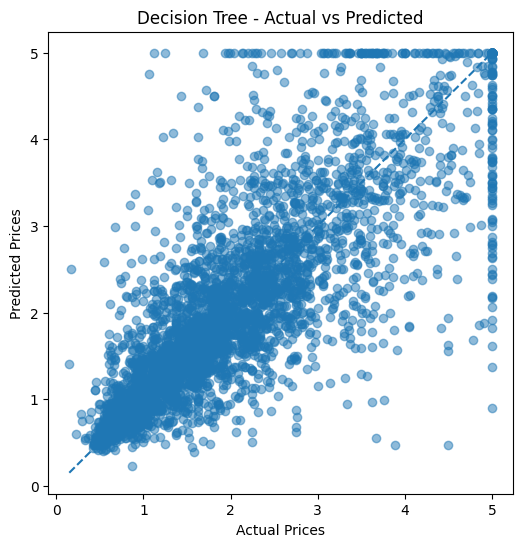

In [5]:
# ======================
# 1. Imports
# ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================
# 2. Load Dataset
# ======================
data = fetch_california_housing(as_frame=True)
df = data.frame

# ======================
# 3. Features and Target
# ======================
x = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# ======================
# 4. Feature Scaling
# ======================
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# ======================
# 5. Train-Test Split
# ======================
x_train, x_test, y_train, y_test, = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

# ======================
# 6. Train Multiple Models
# ======================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
}

result = {}

# ======================
# 7. Evaluation Loop
# ======================
for name, model in models.items():
    # Train the model
    model.fit(x_train, y_train)

    # Predict on test set
    prediction = model.predict(x_test)

    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    result[name] = {"RMSE": rmse, "R2 Score": r2}

# ======================
# 8. Results Comparison
# ======================
results_df = pd.DataFrame(result).T
print("\n📊 Model Comparison:")
print(results_df)

# ======================
# 9. Visualization Comparison
# ======================

# Visualize all models together
plt.figure(figsize=(15,5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(x_test)

    plt.subplot(1, 4, i+1)
    plt.scatter(y_test, y_pred, alpha=0.5)

    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(name)

    # perfect prediction line
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             linestyle='--')

plt.tight_layout()
plt.show()

# Combined plot for all models
plt.figure(figsize=(6,6))

for name, model in models.items():
    y_pred = model.predict(x_test)
    plt.scatter(y_test, y_pred, alpha=0.3, label=name)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("All Models Comparison")
plt.legend()
plt.show()


# ======================
# 10. Best Model Selection
# ======================
best_model_name = results_df["R2 Score"].idxmax()
best_model = models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}"
      f"\nRMSE: {results_df.loc[best_model_name, 'RMSE']:.4f}"
      f"\nR2 Score: {results_df.loc[best_model_name, 'R2 Score']:.4f}")


# ======================
# 11. Model Justification
# ======================
print("\n📌 Model Selection Justification:")
print(f"{best_model_name} performed best because it achieved the highest R2 score "
      "and lowest RMSE, indicating better prediction accuracy.")
print("It is capable of capturing non-linear relationships in the dataset, "
      "which linear models could not handle effectively.")

# ======================
# 12. Visualize the best model separately
# ======================
best_model = models[best_model_name]
y_pred = best_model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title(f"{best_model_name} - Actual vs Predicted")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()
